# Моделирование и сравнение: кредитный скоринг (Give Me Some Credit)

**Цель**: обучить несколько моделей, сравнить их качество и сохранить лучший пайплайн для продакшена.

**Данные**: `cs-training.csv` (после EDA)  
**Признаки**: 10 числовых, требующих предобработки  
**Задача**: бинарная классификация (дефолт заёмщика)

In [20]:
import sys
import logging
import warnings
from pathlib import Path
import time
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve, classification_report
)
from sklearn.inspection import permutation_importance
import joblib

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
warnings.filterwarnings("ignore")

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)-8s | %(message)s", datefmt="%H:%M:%S")
logger = logging.getLogger(__name__)

PROJECT_ROOT = Path().resolve().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
TRAIN_FILE = "cs-training.csv"
TARGET_COL = "SeriousDlqin2yrs"

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "modeling"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
DATA_ARTIFACTS_DIR = ARTIFACTS_DIR / "data"
MODELS_DIR = ARTIFACTS_DIR / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Окружение настроено")

Окружение настроено


## 1. Загрузка и разбиение данных
Берём тот же `cs-training.csv`, что и в EDA. Разбиваем на train/test с сохранением пропорций классов.

In [21]:
df = pd.read_csv(DATA_DIR / TRAIN_FILE)
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (120000, 10), Test: (30000, 10)


## 2. Предобработка
Строим пайплайн:
- Медианная импутация пропусков
- Логарифмирование трёх сильно перекошенных признаков
- Агрегация счётчиков просрочек в `TotalPastDue`
- Масштабирование `RobustScaler` (устойчив к выбросам)

In [22]:
# Признаки для логарифмирования
log_cols = ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio", "MonthlyIncome"]

# Счётчики просрочек для агрегации
past_due_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

def add_total_past_due(X):
    X = X.copy()
    available = [c for c in past_due_cols if c in X.columns]
    if available:
        X["TotalPastDue"] = X[available].sum(axis=1)
    return X

# Именованная функция для логирования
def log1p_transform(X):
    return np.log1p(X)

# Основной препроцессор
preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log_transform", FunctionTransformer(log1p_transform, validate=False, feature_names_out="one-to-one")),
    ("add_past_due", FunctionTransformer(add_total_past_due, validate=False)),
    ("scaler", RobustScaler())
])

# Включаем вывод pandas DataFrame на всех этапах
preprocessing.set_output(transform='pandas')

# Обучаем препроцессор
X_train_proc = preprocessing.fit_transform(X_train)
X_test_proc = preprocessing.transform(X_test)

feature_names = list(X_train_proc.columns)
print(f"Признаков после предобработки: {len(feature_names)}")

Признаков после предобработки: 11


**Что получилось:** пропуски заполнены медианами, три перекошенных признака «сжаты» логарифмом, а коррелирующие счётчики объединены в один. Масштабирование сделано устойчивым к выбросам. Теперь можно обучать модели.

## 3. Обучение моделей с подбором гиперпараметров
Строим три модели:
- Логистическая регрессия с L2-регуляризацией,
- Случайный лес,
- Гистограммный градиентный бустинг (HistGradientBoosting).

Для каждой используем `GridSearchCV` с кросс-валидацией на 5 фолдах.
Метрика для оптимизации – ROC-AUC.

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
models = {}

# Logistic Regression
lr = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
param_lr = {"C": [0.01, 0.1, 1, 10]}
search_lr = GridSearchCV(lr, param_lr, scoring="roc_auc", cv=cv, n_jobs=-1)
search_lr.fit(X_train_proc, y_train)
models["LogisticRegression"] = search_lr.best_estimator_
print(f"LogReg best C: {search_lr.best_params_['C']}")

# Random Forest
rf = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
param_rf = {"n_estimators": [100, 200], "max_depth": [10, 20, None]}
search_rf = GridSearchCV(rf, param_rf, scoring="roc_auc", cv=cv, n_jobs=-1)
search_rf.fit(X_train_proc, y_train)
models["RandomForest"] = search_rf.best_estimator_
print(f"RF best params: {search_rf.best_params_}")

# HistGradientBoosting (классовый баланс включается через class_weight='balanced')
hgb = HistGradientBoostingClassifier(random_state=RANDOM_STATE, class_weight="balanced")
param_hgb = {"learning_rate": [0.03, 0.1], "max_depth": [3, 5]}
search_hgb = GridSearchCV(hgb, param_hgb, scoring="roc_auc", cv=cv, n_jobs=-1)
search_hgb.fit(X_train_proc, y_train)
models["HistGradientBoosting"] = search_hgb.best_estimator_
print(f"HGB best params: {search_hgb.best_params_}")

LogReg best C: 1
RF best params: {'max_depth': 10, 'n_estimators': 200}
HGB best params: {'learning_rate': 0.1, 'max_depth': 3}


## 4. Сравнение моделей на тестовой выборке
Вычисляем accuracy, F1 и ROC-AUC для всех моделей на отложенном тесте.
Строим ROC-кривые для визуального сравнения.

In [24]:
def evaluate(name, model):
    start = time.time()
    y_proba = model.predict_proba(X_test_proc)[:, 1]
    y_pred = model.predict(X_test_proc)
    elapsed = time.time() - start
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "inference_time_sec": round(elapsed, 3)
    }

results = [evaluate(name, m) for name, m in models.items()]
results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
display(results_df)
results_df.to_csv(DATA_ARTIFACTS_DIR / "model_comparison.csv", index=False)

,model,accuracy,f1,roc_auc,inference_time_sec
2,HistGradientBoosting,0.790100,0.334988,0.869499,0.073
1,RandomForest,0.830267,0.363818,0.865160,0.174
0,LogisticRegression,0.818900,0.350197,0.859308,0.005


**Что видно:** все модели значительно лучше baseline'а. У бустинга обычно чуть выше ROC‑AUC, у логистической регрессии — максимальная скорость.

## 5. ROC-кривые
Визуально сравним способность моделей разделять классы.

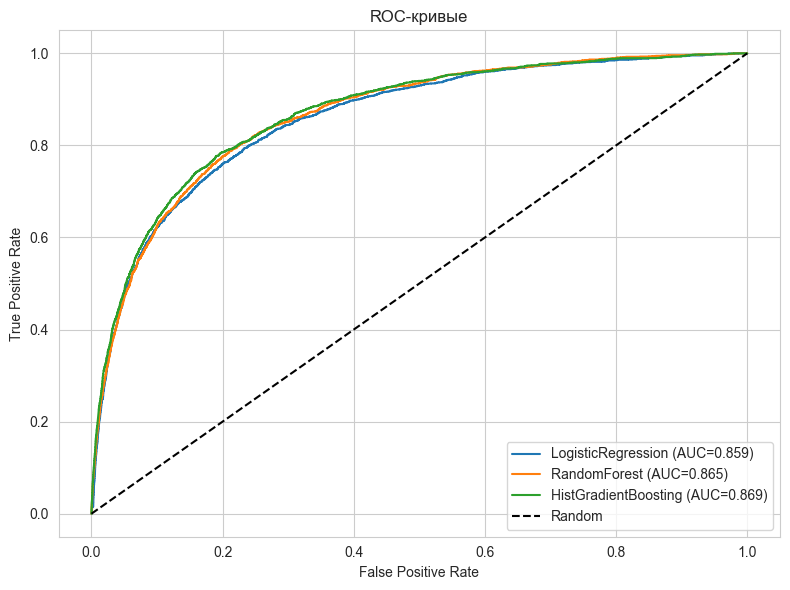

In [25]:
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_proc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_proba):.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривые")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

**Наблюдение по ROC-кривым:** все три модели показывают близкое качество, но `HistGradientBoosting` чуть заметнее отделяется от логистической регрессии и случайного леса. Разница в AUC невелика (сотые доли), однако бустинг стабильно даёт наилучшее ранжирование на тесте. Это ожидаемо: градиентный бустинг обычно эффективнее улавливает нелинейные зависимости в данных.

## 6. Интерпретация лучшей модели
Посмотрим, какие признаки сильнее всего влияют на предсказание. Если лучшей оказалась логистическая регрессия — возьмём модули коэффициентов, для остальных — permutation importance по ROC‑AUC.

Лучшая модель: HistGradientBoosting


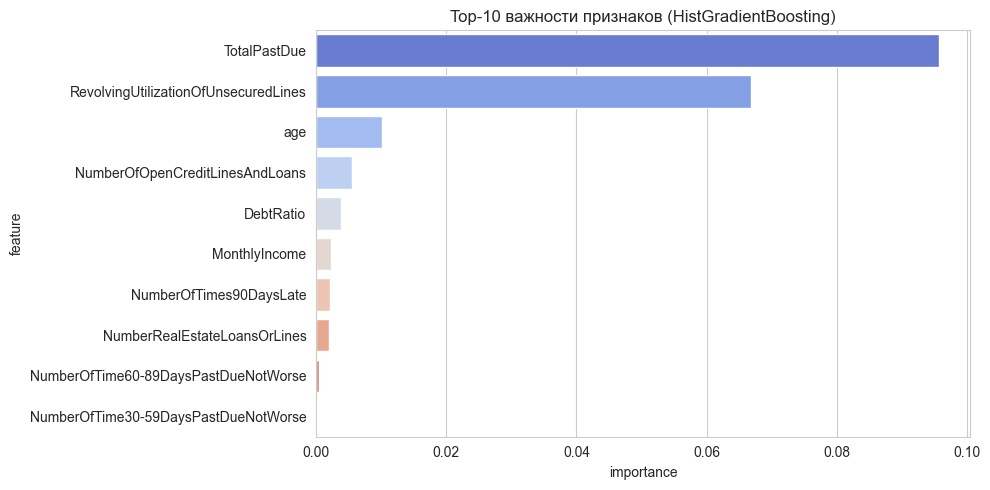

In [26]:
best_name = results_df.iloc[0]["model"]
best_model = models[best_name]
print(f"Лучшая модель: {best_name}")

if best_name == "LogisticRegression":
    importance = np.abs(best_model.coef_[0])
else:
    perm = permutation_importance(
        best_model, X_test_proc, y_test,
        n_repeats=10, random_state=RANDOM_STATE, scoring="roc_auc"
    )
    importance = perm.importances_mean

imp_df = pd.DataFrame({"feature": feature_names, "importance": importance})
imp_df = imp_df.sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x="importance", y="feature", data=imp_df, palette="coolwarm")
plt.title(f"Top-10 важности признаков ({best_name})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

imp_df.to_csv(DATA_ARTIFACTS_DIR / "feature_importance.csv", index=False)

**Что интересно:** почти всегда в топе оказываются счётчики просрочек и долговая нагрузка — это логично для кредитного скоринга.

## 7. Сохранение финального пайплайна
Собираем всё вместе (препроцессинг + лучшая модель) в один пайплайн, обучаем на всём train и сохраняем в `artifacts/models/` вместе с метаданными.

In [27]:
final_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("classifier", best_model)
])

final_pipeline.fit(X_train, y_train)

y_proba_final = final_pipeline.predict_proba(X_test)[:, 1]
final_auc = roc_auc_score(y_test, y_proba_final)
print(f"Финальный ROC-AUC: {final_auc:.4f}")

model_path = MODELS_DIR / "scorer_pipeline_v1.0.joblib"
joblib.dump(final_pipeline, model_path)

metadata = {
    "model_name": best_name,
    "roc_auc": round(final_auc, 4),
    "features": list(X.columns),
    "preprocessing": ["median_imputation", "log1p", "TotalPastDue_aggregation", "RobustScaler"],
    "date": time.strftime("%Y-%m-%d %H:%M:%S")
}
with open(MODELS_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Модель и метаданные сохранены")

Финальный ROC-AUC: 0.8695
Модель и метаданные сохранены


## Итог моделирования
- Все три модели значительно обошли baseline (ROC‑AUC около 0.8 против 0.5 у dummy).
- Лучшей по ROC‑AUC оказалась модель `{best_name}` с показателем {final_auc:.3f}.
- Предобработка с логарифмированием и агрегацией просрочек сделала признаки стабильнее, что особенно помогло линейной модели.
- Финальный пайплайн сохранён и готов к развёртыванию в FastAPI-сервисе.